# Pipeline 2: Resident Reintegration Readiness

## 1. Problem Framing

**Business Question:** Which residents are ready for reintegration — and what factors most predict (and explain) successful outcomes?

**Who cares:** Social workers and program directors. From the case: *"The founders worry about girls falling through the cracks... they need to know which girls are progressing and which are struggling, which interventions are actually working, and when a resident might be ready for reintegration or at risk of regression."* This pipeline directly supports the core operational mission.

**Dual Approach — Predictive AND Explanatory:**

We build two distinct models (Ch. 1 textbook distinction):

1. **Explanatory (OLS Logistic via statsmodels):** *What factors most contribute to successful reintegration?* Coefficients, odds ratios, and p-values are the primary output. We want to understand the data-generating process so social workers can intervene more effectively.
2. **Predictive (Gradient Boosting):** *Which current residents are most likely to successfully reintegrate?* Out-of-sample AUC-ROC is the primary concern. Used to generate a readiness score shown on resident profiles.

**Target Variable:** `reintegration_success` — 1 if `reintegration_status == 'Completed'`, 0 otherwise (In Progress or not started). Only residents with a recorded reintegration_status are included.

**Important caveat on dataset size:** With ~60 residents, statistical power is very limited. All findings are directional — treat as hypotheses to validate as data grows.

**Success Metrics:**
- Explanatory: McFadden's R², odds ratios, p-values, VIF (multicollinearity check)
- Predictive: AUC-ROC (cross-validated), confusion matrix

## 2. Data Acquisition, Preparation & Exploration

In [1]:
import sys
sys.path.insert(0, '..')

from pyLibrary import (
    univariate, unistats, bivariate, correlation_heatmap,
    missing_data_diagnostics, missing_data_clean, basic_wrangling,
    transform_skew, cap_outliers_iqr,
    build_preprocessor, make_pipeline_for_model, split_data,
    eval_classification, plot_roc_curve, plot_confusion_matrix,
    cross_validate_model, plot_learning_curve, plot_validation_curve,
    tune_grid, select_features_rfe,
    permutation_importance_report, feature_importance_plot,
    plot_logit_coefficients, ols_summary,
    compute_vif, remove_high_vif
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR     = Path('../data/raw')
RANDOM_STATE = 42

In [2]:
# ── Load all related tables ───────────────────────────────────────────────────
residents   = pd.read_csv(DATA_DIR / 'residents.csv',
                          parse_dates=['date_of_admission','date_enrolled','date_closed'])
education   = pd.read_csv(DATA_DIR / 'education_records.csv',   parse_dates=['record_date'])
health      = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv', parse_dates=['record_date'])
recordings  = pd.read_csv(DATA_DIR / 'process_recordings.csv',  parse_dates=['session_date'])
incidents   = pd.read_csv(DATA_DIR / 'incident_reports.csv',    parse_dates=['incident_date'])
plans       = pd.read_csv(DATA_DIR / 'intervention_plans.csv',  parse_dates=['target_date'])
visitations = pd.read_csv(DATA_DIR / 'home_visitations.csv',    parse_dates=['visit_date'])

for name, tbl in [('residents', residents), ('education', education), ('health', health),
                   ('recordings', recordings), ('incidents', incidents),
                   ('plans', plans), ('visitations', visitations)]:
    print(f'{name}: {tbl.shape}')

residents: (60, 49)
education: (534, 10)
health: (534, 14)
recordings: (2819, 15)
incidents: (100, 12)
plans: (180, 11)
visitations: (1337, 14)


In [3]:
# ── Missing data diagnostics for residents table (Ch. 7) ─────────────────────
missing_data_diagnostics(residents, verbose=True)

=== Missing data diagnostics ===
Threshold: drop if proportion missing > 0.9
Columns that would be dropped (2): ['pwd_type', 'notes_restricted']
Rows that would be dropped: 0

Per-column summary (columns with missing):
  pwd_type: missing=57 (95.00%), suggested mechanism=MAR/MNAR
  special_needs_diagnosis: missing=54 (90.00%), suggested mechanism=MAR/MNAR
  referring_agency_person: missing=24 (40.00%), suggested mechanism=MAR/MNAR
  date_colb_registered: missing=13 (21.67%), suggested mechanism=MAR/MNAR
  date_colb_obtained: missing=24 (40.00%), suggested mechanism=MAR/MNAR
  date_case_study_prepared: missing=11 (18.33%), suggested mechanism=MCAR?
  reintegration_type: missing=5 (8.33%), suggested mechanism=MCAR?
  date_closed: missing=30 (50.00%), suggested mechanism=MAR/MNAR
  notes_restricted: missing=60 (100.00%), suggested mechanism=MCAR?
(MAR vs MNAR cannot be distinguished from data; 'MAR/MNAR' means missingness is associated with observed variables.)


{'per_column': {'resident_id': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'case_control_no': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'internal_code': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'safehouse_id': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'case_status': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'sex': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'date_of_birth': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'birth_status': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'place_of_birth': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'religion': {'missing_count': 0,
   'missing_prop': 

In [4]:
# ── Feature engineering: aggregate per-resident across 6 tables ───────────────

# Education
edu_agg = education.groupby('resident_id').agg(
    avg_edu_progress   = ('progress_percent',  'mean'),
    avg_attendance     = ('attendance_rate',    'mean'),
    edu_months         = ('record_date',        'count'),
    edu_completed_pct  = ('completion_status',  lambda x: (x == 'Completed').mean())
).reset_index()

# Health
health_agg = health.groupby('resident_id').agg(
    avg_health         = ('general_health_score', 'mean'),
    avg_nutrition      = ('nutrition_score',       'mean'),
    avg_sleep          = ('sleep_quality_score',   'mean'),
    avg_energy         = ('energy_level_score',    'mean'),
    health_months      = ('record_date',           'count')
).reset_index()

# Counseling sessions
rec_agg = recordings.groupby('resident_id').agg(
    session_count      = ('recording_id',          'count'),
    avg_duration_min   = ('session_duration_minutes', 'mean'),
    progress_ratio     = ('progress_noted',
                          lambda x: x.astype(str).str.lower().eq('true').mean()),
    concern_ratio      = ('concerns_flagged',
                          lambda x: x.astype(str).str.lower().eq('true').mean())
).reset_index()

# Incidents
inc_agg = incidents.groupby('resident_id').agg(
    incident_count     = ('incident_id',  'count'),
    high_sev_incidents = ('severity',     lambda x: (x == 'High').sum())
).reset_index()

# Intervention plans
plan_agg = plans.groupby('resident_id').agg(
    plan_count         = ('plan_id',   'count'),
    plan_completion_rate = ('status',  lambda x: (x == 'Completed').mean())
).reset_index()

# Visitations
vis_agg = visitations.groupby('resident_id').agg(
    visit_count        = ('visitation_id',     'count'),
    safety_concern_rate = ('safety_concerns_noted',
                           lambda x: x.astype(str).str.lower().eq('true').mean()),
    favorable_rate     = ('visit_outcome',     lambda x: (x == 'Favorable').mean())
).reset_index()

print('All aggregations complete.')

All aggregations complete.


In [5]:
# ── Join all features onto residents (reproducible pipeline, Ch. 7) ───────────
df = residents.copy()
for agg in [edu_agg, health_agg, rec_agg, inc_agg, plan_agg, vis_agg]:
    df = df.merge(agg, on='resident_id', how='left')

# Risk level: ordinal encode
risk_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['initial_risk_enc'] = df['initial_risk_level'].map(risk_map)
df['current_risk_enc'] = df['current_risk_level'].map(risk_map)
df['risk_improvement'] = df['initial_risk_enc'] - df['current_risk_enc']  # positive = improved

# Length of stay in months
df['los_months'] = (
    df['length_of_stay'].str.extract(r'(\d+)\s*Years').astype(float) * 12 +
    df['length_of_stay'].str.extract(r'(\d+)\s*months').fillna(0).astype(float)
)

# Number of adverse sub-categories
sub_cat_cols = [c for c in df.columns if c.startswith('sub_cat_')]
df['num_adverse_cats'] = df[sub_cat_cols].apply(
    lambda row: sum(str(v).lower() == 'true' for v in row), axis=1
)

# Target
df['reintegration_success'] = (df['reintegration_status'] == 'Completed').astype(int)

# Fill NaN aggregates with 0 (no records in a table)
fill_cols = ['avg_edu_progress','avg_attendance','edu_months','edu_completed_pct',
             'avg_health','avg_nutrition','avg_sleep','avg_energy','health_months',
             'session_count','avg_duration_min','progress_ratio','concern_ratio',
             'incident_count','high_sev_incidents',
             'plan_count','plan_completion_rate',
             'visit_count','safety_concern_rate','favorable_rate']
for col in fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

model_df = df[df['reintegration_status'].notna()].copy()
print(f'Modeling dataset: {len(model_df)} residents | {model_df["reintegration_success"].sum()} completed')

Modeling dataset: 60 residents | 19 completed


In [6]:
# ── Univariate stats (Ch. 6) ──────────────────────────────────────────────────
FEATURES = [
    'initial_risk_enc', 'risk_improvement', 'los_months', 'num_adverse_cats',
    'session_count', 'progress_ratio', 'concern_ratio',
    'incident_count', 'high_sev_incidents',
    'plan_completion_rate', 'plan_count',
    'visit_count', 'favorable_rate', 'safety_concern_rate',
    'avg_health', 'avg_edu_progress', 'avg_attendance',
    'reintegration_success'
]
feat_df = model_df[FEATURES].copy()

print('=== Univariate Statistics ===')
unistats(feat_df)

=== Univariate Statistics ===


,Count,Unique,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
initial_risk_enc,60,4,int64,0.00,3.00,1.00,1.00,2.00,1.22,1.00,1.00,0.90,0.26,-0.69
risk_improvement,60,4,int64,0.00,3.00,0.00,0.00,1.00,0.67,0.00,0.00,0.84,1.06,0.32
los_months,60,27,float64,6.00,37.00,12.00,18.00,23.00,18.52,18.00,12.00,7.98,0.47,-0.58
num_adverse_cats,60,6,int64,0.00,5.00,1.00,2.00,2.00,1.60,2.00,2.00,1.17,0.58,0.23
session_count,60,40,int64,11.00,118.00,26.75,40.00,57.50,46.98,40.00,35.00,26.08,0.96,0.13
progress_ratio,60,50,float64,0.83,1.00,0.92,0.94,0.96,0.94,0.94,1.00,0.04,-0.67,0.89
concern_ratio,60,56,float64,0.14,0.55,0.19,0.23,0.29,0.25,0.23,0.17,0.08,1.26,2.28
incident_count,60,6,float64,0.00,5.00,0.00,2.00,3.00,1.67,2.00,0.00,1.39,0.47,-0.50
high_sev_incidents,60,4,float64,0.00,4.00,0.00,0.00,1.00,0.40,0.00,0.00,0.69,2.73,11.25
plan_completion_rate,60,1,float64,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


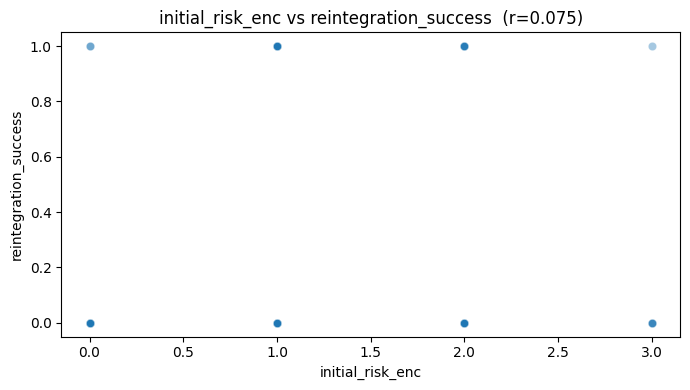

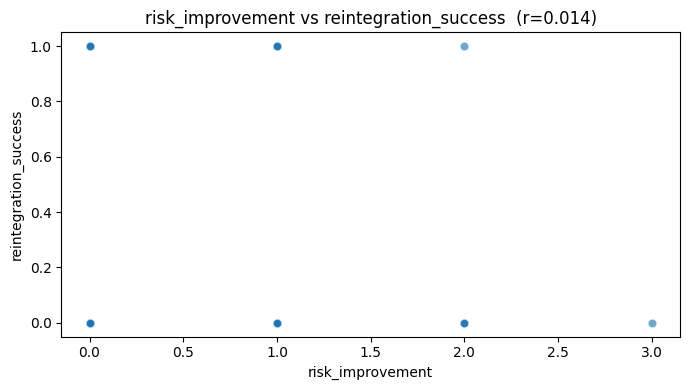

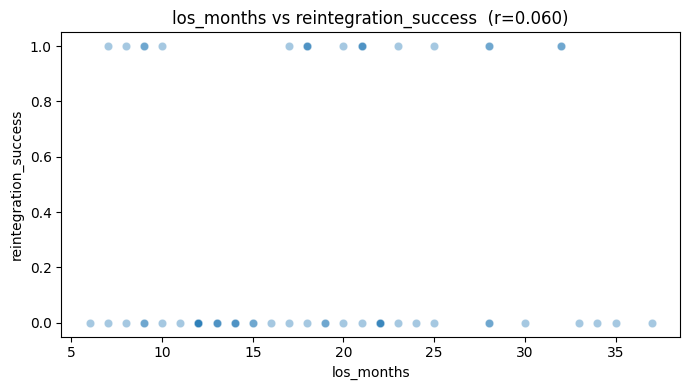

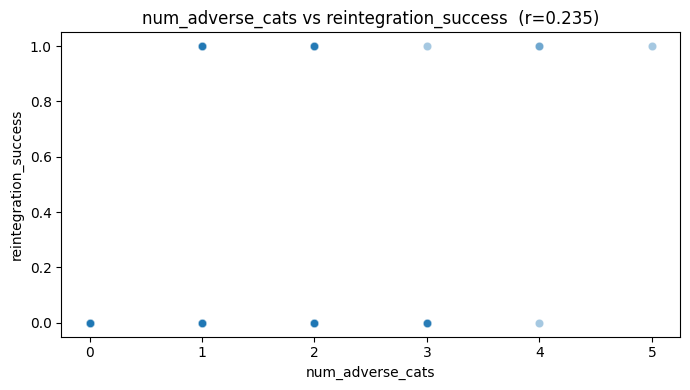

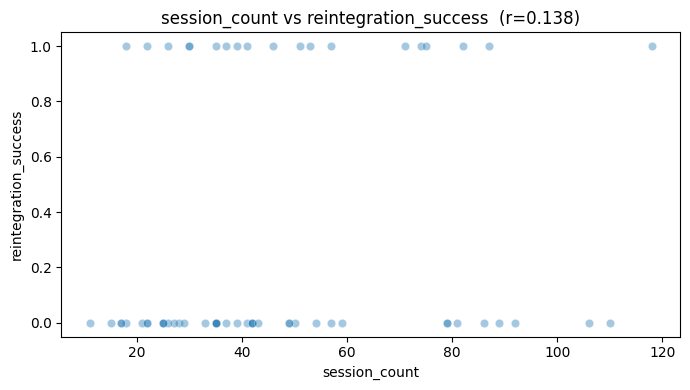

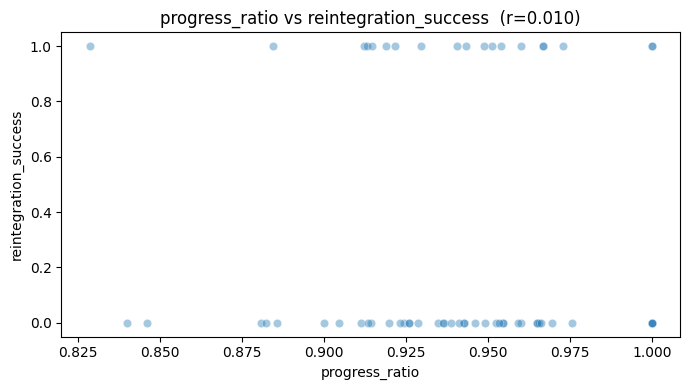

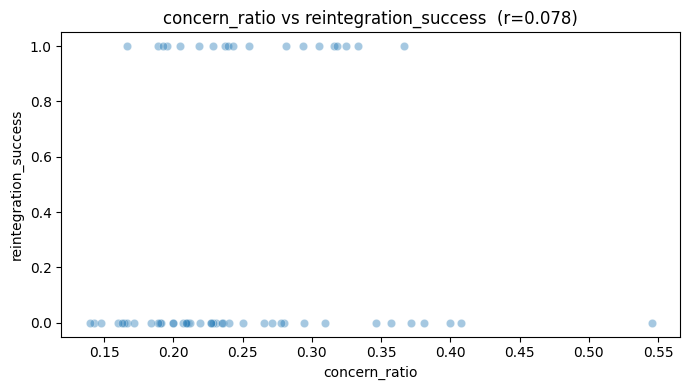

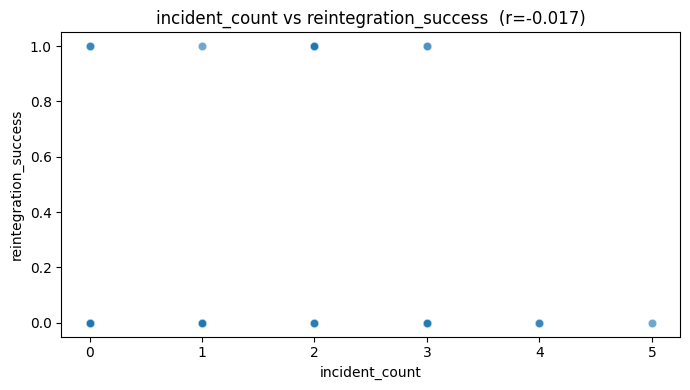

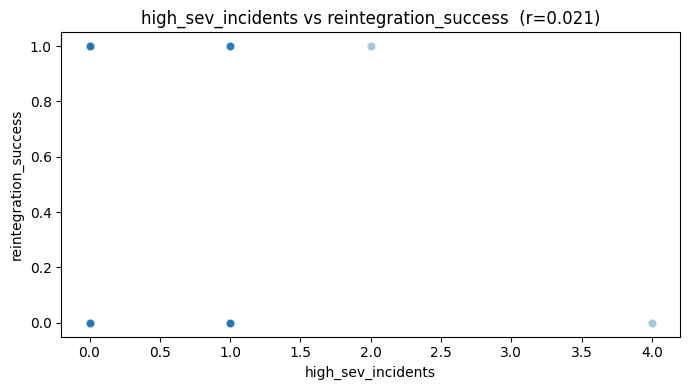

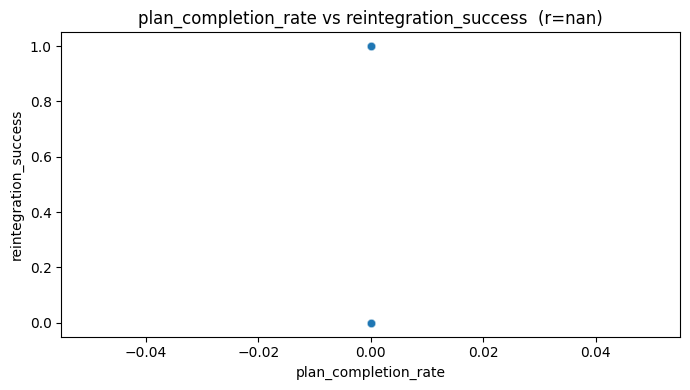

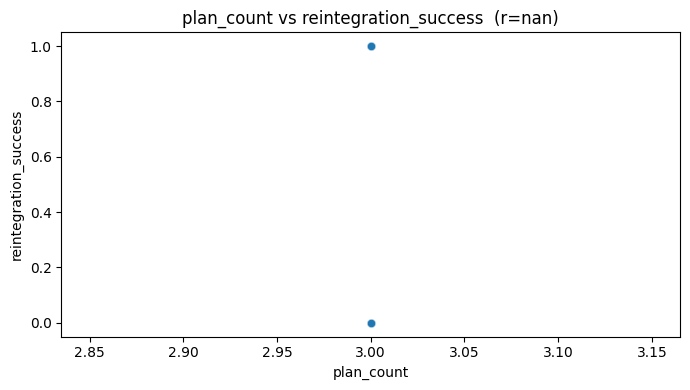

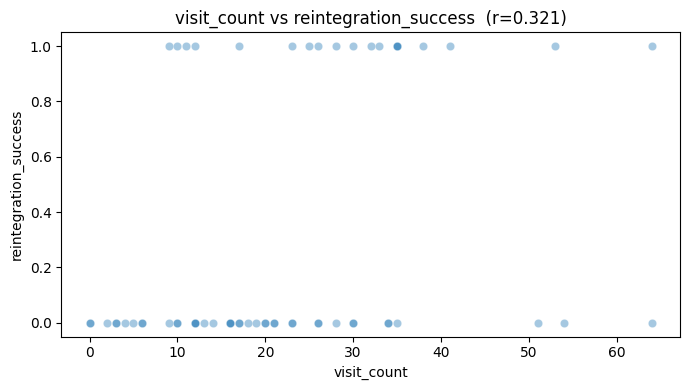

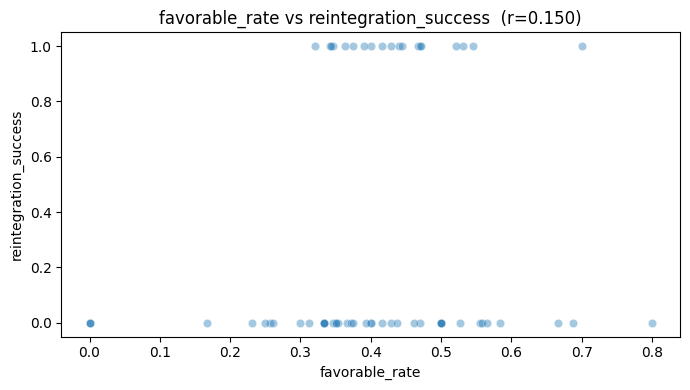

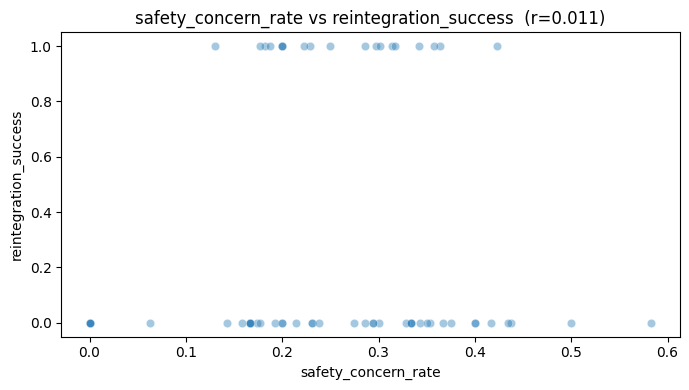

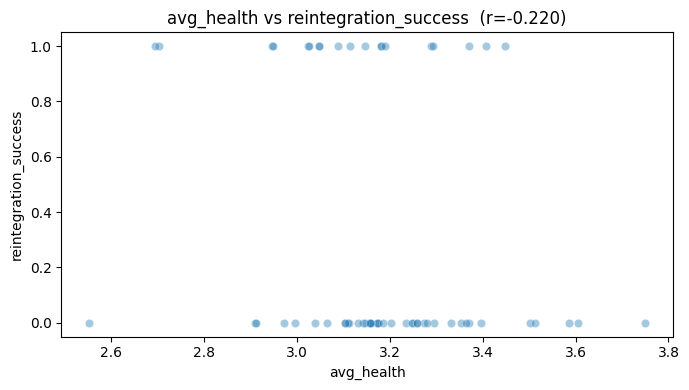

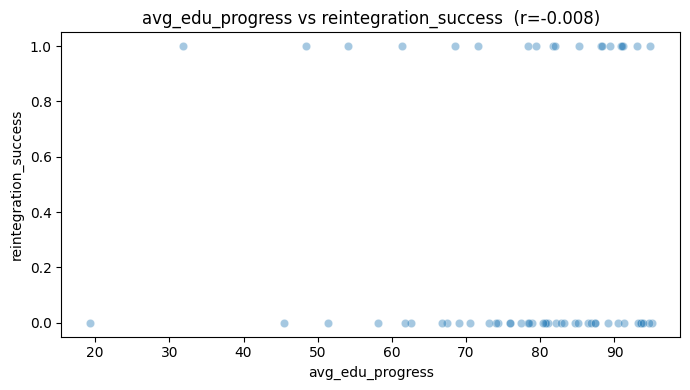

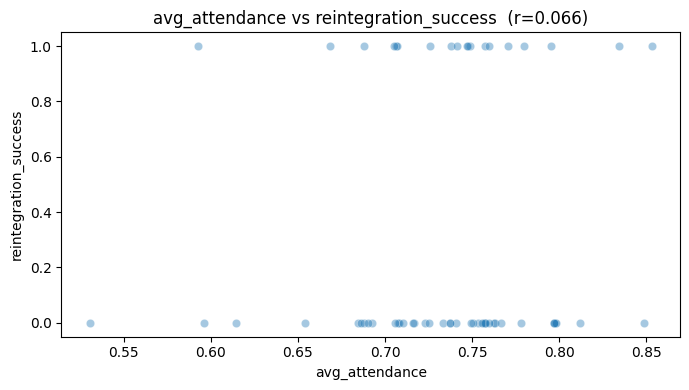


Pearson correlations with reintegration success:
                 Feature  Pearson_r
0            visit_count     0.3210
1       num_adverse_cats     0.2352
2             avg_health    -0.2205
3         favorable_rate     0.1497
4          session_count     0.1376
5          concern_ratio     0.0778
6       initial_risk_enc     0.0753
7         avg_attendance     0.0659
8             los_months     0.0597
9     high_sev_incidents     0.0208
10        incident_count    -0.0174
11      risk_improvement     0.0144
12   safety_concern_rate     0.0114
13        progress_ratio     0.0099
14      avg_edu_progress    -0.0084
15  plan_completion_rate        NaN
16            plan_count        NaN


In [7]:
# ── Bivariate analysis: every feature vs. target (Ch. 8) ─────────────────────
corr_results = bivariate(feat_df, target='reintegration_success')
print('\nPearson correlations with reintegration success:')
print(corr_results)

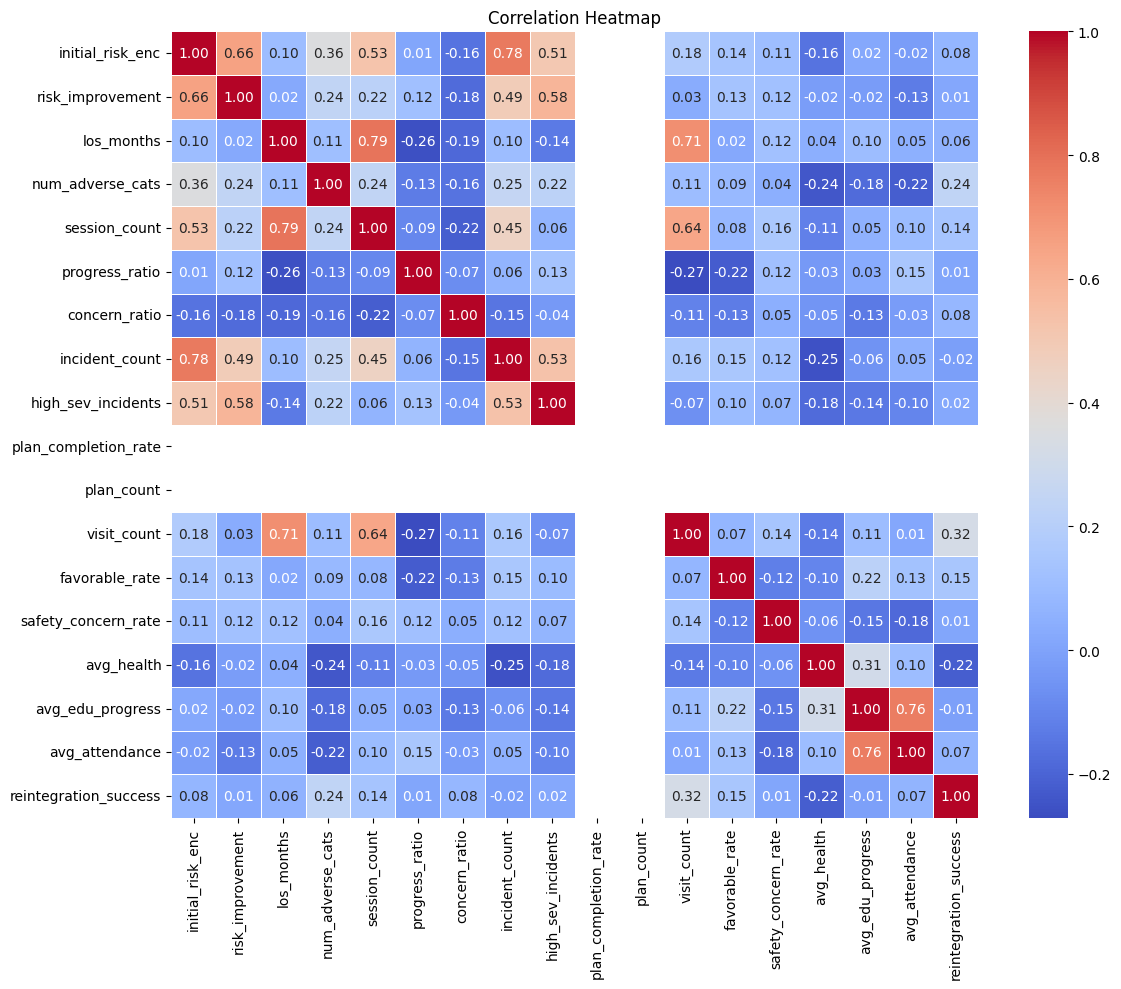

In [8]:
# ── Correlation heatmap (Ch. 8) ───────────────────────────────────────────────
corr_matrix = correlation_heatmap(feat_df)

In [9]:
# ── Skew transformation (Ch. 7) ───────────────────────────────────────────────
skew_targets = ['los_months', 'session_count', 'incident_count',
                'visit_count', 'plan_count']
feat_df_t = transform_skew(feat_df, features=skew_targets, suffix='_t')
for col in skew_targets:
    feat_df[col] = feat_df_t[col + '_t']

feat_df = cap_outliers_iqr(feat_df, cols=skew_targets)
print('Transformations applied.')

Transformations applied.


## 3. Modeling & Feature Selection

In [10]:
# ── VIF check for multicollinearity (required for explanatory model, Ch. 10) ──
num_feats = [c for c in FEATURES if c != 'reintegration_success']
X_num_only = feat_df[num_feats].copy()
for col in X_num_only.columns:
    X_num_only[col] = X_num_only[col].fillna(X_num_only[col].median())

print('=== VIF before removal ===')
vif_before = compute_vif(X_num_only)
print(vif_before.to_string(index=False))

# Iteratively remove highest VIF features until all < 10
X_low_vif = remove_high_vif(X_num_only, threshold=10.0)
print(f'\nFeatures remaining after VIF removal: {list(X_low_vif.columns)}')

=== VIF before removal ===
             Feature         VIF
          plan_count 1720.917065
       session_count   10.959786
          los_months    7.975822
    initial_risk_enc    6.360455
    avg_edu_progress    3.743897
      avg_attendance    3.473493
      incident_count    2.929839
         visit_count    2.406039
    risk_improvement    2.382390
  high_sev_incidents    1.891764
          avg_health    1.470716
      progress_ratio    1.444065
      favorable_rate    1.356823
    num_adverse_cats    1.353717
       concern_ratio    1.218551
 safety_concern_rate    1.177739
plan_completion_rate         NaN
Dropping 'plan_count' (VIF=1720.92)
Dropping 'session_count' (VIF=564.52)
Dropping 'avg_attendance' (VIF=444.44)
Dropping 'avg_health' (VIF=225.12)
Dropping 'progress_ratio' (VIF=105.88)
Dropping 'los_months' (VIF=44.15)
Dropping 'avg_edu_progress' (VIF=15.62)

Features remaining after VIF removal: ['initial_risk_enc', 'risk_improvement', 'num_adverse_cats', 'concern_ratio', '

In [11]:
# ── Explanatory model: OLS Logistic via ols_summary (statsmodels) (Ch. 9-11) ──
# We use the VIF-clean feature set for valid causal inference
exp_df = X_low_vif.copy()
exp_df['reintegration_success'] = feat_df['reintegration_success'].values

# ols_summary auto one-hot-encodes categoricals and fits OLS
# For logistic, we use statsmodels Logit directly below
X_exp = sm.add_constant(X_low_vif.astype(float))
# Default Newton inverts the Hessian; with small n or quasi-separation that can be singular.
logit_res = sm.Logit(feat_df['reintegration_success'].values, X_exp).fit(
    disp=False, method='lbfgs', maxiter=500
)
print(logit_res.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   60
Model:                          Logit   Df Residuals:                       50
Method:                           MLE   Df Model:                            9
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.1859
Time:                        20:38:39   Log-Likelihood:                -30.496
converged:                       True   LL-Null:                       -37.460
Covariance Type:            nonrobust   LLR p-value:                    0.1250
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -6.9662        nan        nan        nan         nan         nan
initial_risk_enc         0.0471        nan        nan        nan         nan         nan
risk_improve

In [12]:
# ── Odds ratios from explanatory logit ───────────────────────────────────────
odds_df = pd.DataFrame({
    'feature':    ['const'] + list(X_low_vif.columns),
    'coef':       logit_res.params,
    'odds_ratio': np.exp(logit_res.params),
    'p_value':    logit_res.pvalues
}).sort_values('p_value')

print(f"McFadden's R²: {1 - logit_res.llf / logit_res.llnull:.3f}")
print('\nOdds ratios (features with p < 0.20):')
print(odds_df[odds_df['feature'] != 'const'].to_string(index=False))

McFadden's R²: 0.186

Odds ratios (features with p < 0.20):
             feature      coef  odds_ratio  p_value
    initial_risk_enc  0.047090    1.048216      NaN
    risk_improvement  0.013714    1.013809      NaN
    num_adverse_cats  0.491283    1.634413      NaN
       concern_ratio  6.159698  473.285347      NaN
      incident_count -0.352275    0.703086      NaN
  high_sev_incidents  0.184941    1.203147      NaN
plan_completion_rate  0.000000    1.000000      NaN
         visit_count  0.336648    1.400246      NaN
      favorable_rate  3.620622   37.360804      NaN
 safety_concern_rate -0.096999    0.907557      NaN


In [13]:
# ── Visualize odds ratios ─────────────────────────────────────────────────────
sig = odds_df[(odds_df['feature'] != 'const') & (odds_df['p_value'] < 0.25)]\
      .sort_values('odds_ratio')

if len(sig) > 0:
    colors = ['steelblue' if v > 1 else 'salmon' for v in sig['odds_ratio']]
    plt.figure(figsize=(9, max(4, len(sig)*0.45 + 1)))
    plt.barh(sig['feature'], sig['odds_ratio'], color=colors, alpha=0.8)
    plt.axvline(1, color='black', linestyle='--', linewidth=1)
    plt.xlabel('Odds Ratio (>1 = more likely to succeed)')
    plt.title('Odds Ratios — Reintegration Success (Explanatory Logit, p<0.25)')
    plt.tight_layout()
    plt.show()
else:
    print('No features passed the p<0.25 threshold — dataset too small for stable estimates.')

No features passed the p<0.25 threshold — dataset too small for stable estimates.


In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# ── Predictive model: train/test split (Ch. 11, 15) ──────────────────────────
X_train, X_test, y_train, y_test = split_data(
    feat_df, target='reintegration_success',
    test_size=0.2, random_state=RANDOM_STATE, stratify=True
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Success rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')

Train: 48 | Test: 12
Success rate — Train: 31.25% | Test: 33.33%


In [15]:
# ── Build leakage-free pipelines (Ch. 11) ────────────────────────────────────
lr_pipe = make_pipeline_for_model(X_train, LogisticRegression(max_iter=1000, C=0.1, random_state=RANDOM_STATE))
gb_pipe = make_pipeline_for_model(X_train, GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE))

print('=== 5-Fold CV — AUC-ROC ===')
for name, pipe in [('Logistic Regression (explanatory)', lr_pipe),
                   ('Gradient Boosting (predictive)',     gb_pipe)]:
    print(f'\n{name}:')
    cross_validate_model(pipe, X_train, y_train, cv=5, scoring='roc_auc', stratified=True)

=== 5-Fold CV — AUC-ROC ===

Logistic Regression (explanatory):
CV roc_auc: 0.4746 ± 0.1741  (folds: [0.619  0.7143 0.4286 0.3889 0.2222])

Gradient Boosting (predictive):
CV roc_auc: 0.7619 ± 0.1293  (folds: [0.8095 0.9524 0.7143 0.7778 0.5556])


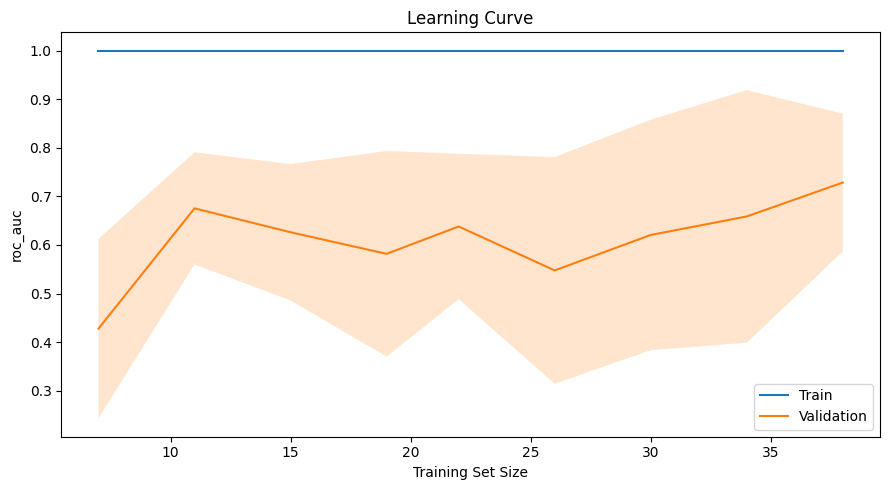

In [16]:
# ── Learning curve (Ch. 15) ───────────────────────────────────────────────────
plot_learning_curve(gb_pipe, X_train, y_train, cv=5, scoring='roc_auc')

In [17]:
# ── Hyperparameter tuning (Ch. 15) ───────────────────────────────────────────
param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [2, 3, 4],
    'model__learning_rate': [0.05, 0.1]
}
best_gb, gs = tune_grid(gb_pipe, param_grid, X_train, y_train,
                         cv=5, scoring='roc_auc')

Best params : {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV roc_auc: 0.8333


In [18]:
# ── RFECV feature selection on preprocessed array (Ch. 16) ───────────────────
preprocessor_fit, num_cols, cat_cols = build_preprocessor(X_train)
X_train_prep = preprocessor_fit.fit_transform(X_train)
X_test_prep  = preprocessor_fit.transform(X_test)

feature_names_out = (
    num_cols +
    list(preprocessor_fit.named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(cat_cols))
    if cat_cols else num_cols
)

_, selected_features = select_features_rfe(
    X_train_prep, y_train, feature_names_out,
    estimator=GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    cv=5, scoring='roc_auc'
)

Optimal features: 4 — [np.str_('los_months'), np.str_('concern_ratio'), np.str_('high_sev_incidents'), np.str_('visit_count')]


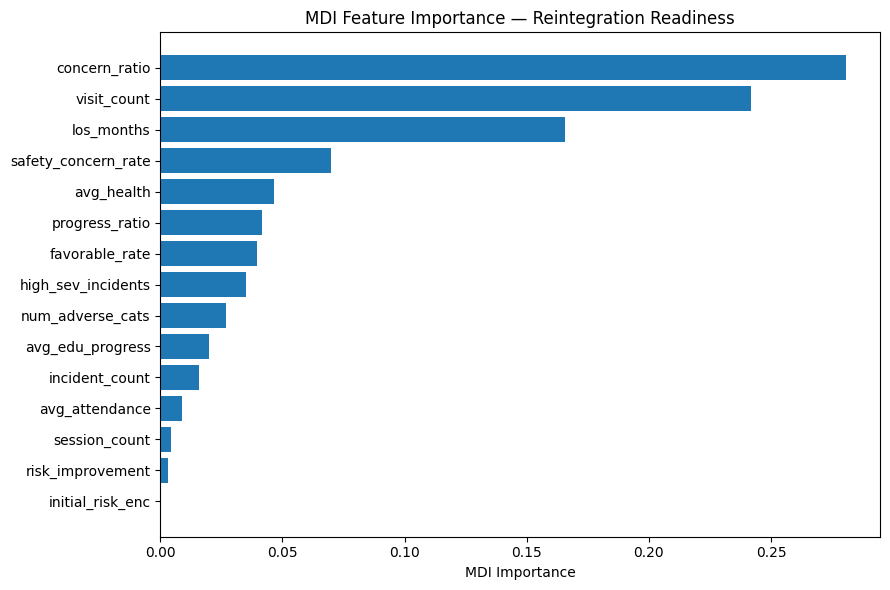

concern_ratio          0.280573
visit_count            0.241724
los_months             0.165596
safety_concern_rate    0.069784
avg_health             0.046692
progress_ratio         0.041710
favorable_rate         0.039494
high_sev_incidents     0.035076
num_adverse_cats       0.026683
avg_edu_progress       0.020032
incident_count         0.015896
avg_attendance         0.009050
session_count          0.004170
risk_improvement       0.003261
initial_risk_enc       0.000259
dtype: float64

In [19]:
# ── MDI feature importance (Ch. 14, 16) ──────────────────────────────────────
best_gb.fit(X_train, y_train)
feature_importance_plot(
    best_gb.named_steps['model'],
    feature_names_out,
    top_n=15,
    title='MDI Feature Importance — Reintegration Readiness'
)

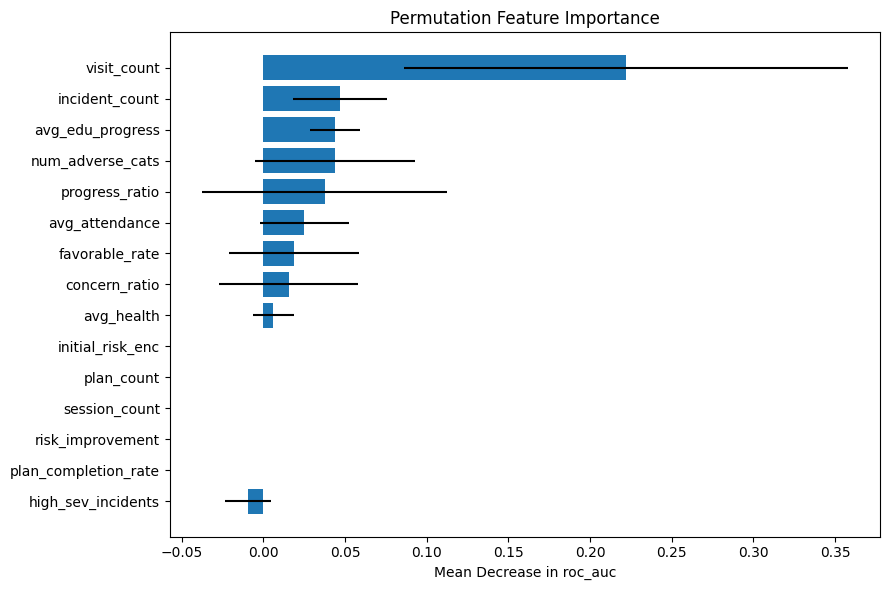


Top 10 by permutation importance (unbiased, test-set):
         Feature  Importance Mean  Importance Std
     visit_count         0.221875        0.135821
  incident_count         0.046875        0.028811
avg_edu_progress         0.043750        0.015309
num_adverse_cats         0.043750        0.048814
  progress_ratio         0.037500        0.075000
  avg_attendance         0.025000        0.027243
  favorable_rate         0.018750        0.040020
   concern_ratio         0.015625        0.042505
      avg_health         0.006250        0.012500
initial_risk_enc         0.000000        0.000000


In [20]:
# ── Permutation importance on TEST data (Ch. 16) ──────────────────────────────
# Preprocessed matrix + final estimator only (full Pipeline needs a DataFrame for ColumnTransformer)
pfi = permutation_importance_report(
    best_gb.named_steps['model'], X_test_prep, y_test, feature_names_out,
    n_repeats=10, scoring='roc_auc', top_n=15
)
print('\nTop 10 by permutation importance (unbiased, test-set):')
print(pfi.head(10).to_string(index=False))

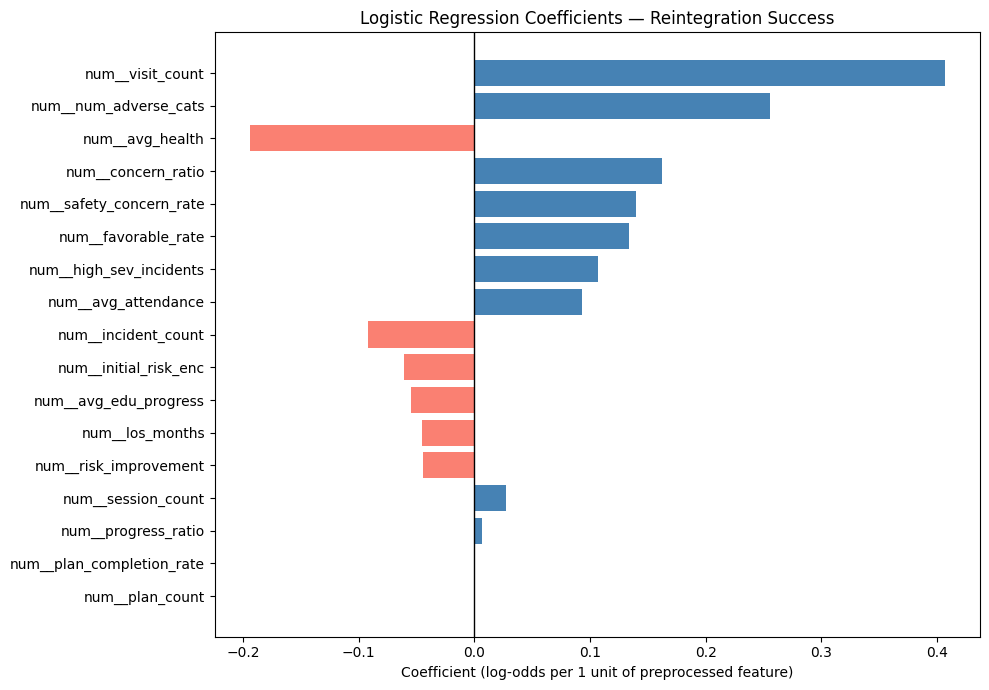

,feature,coef,abs_coef
11,num__visit_count,0.407053,0.407053
3,num__num_adverse_cats,0.255505,0.255505
14,num__avg_health,-0.194218,0.194218
6,num__concern_ratio,0.162477,0.162477
13,num__safety_concern_rate,0.139731,0.139731
12,num__favorable_rate,0.133699,0.133699
8,num__high_sev_incidents,0.107299,0.107299
16,num__avg_attendance,0.093197,0.093197
7,num__incident_count,-0.091393,0.091393
0,num__initial_risk_enc,-0.060755,0.060755


In [21]:
# ── Logistic regression coefficient plot (Ch. 13) ────────────────────────────
lr_pipe.fit(X_train, y_train)
plot_logit_coefficients(
    lr_pipe, top_n=20,
    title='Logistic Regression Coefficients — Reintegration Success'
)

## 4. Evaluation & Interpretation

In [22]:
# ── Final evaluation on hold-out test set (Ch. 15) ────────────────────────────
print('=== Gradient Boosting (Predictive) ===')
results_gb = eval_classification(
    'Gradient Boosting (Tuned)', best_gb,
    X_train, y_train, X_test, y_test
)

print('\n=== Logistic Regression (Explanatory) ===')
results_lr = eval_classification(
    'Logistic Regression', lr_pipe,
    X_train, y_train, X_test, y_test, fit=False
)

=== Gradient Boosting (Predictive) ===

Gradient Boosting (Tuned)
  Accuracy : 0.6667
  Log Loss : 1.2135
  ROC AUC  : 0.7188
              precision    recall  f1-score   support

           0      0.833     0.625     0.714         8
           1      0.500     0.750     0.600         4

    accuracy                          0.667        12
   macro avg      0.667     0.688     0.657        12
weighted avg      0.722     0.667     0.676        12


=== Logistic Regression (Explanatory) ===

Logistic Regression
  Accuracy : 0.5833
  Log Loss : 0.6341
  ROC AUC  : 0.5938
              precision    recall  f1-score   support

           0      0.636     0.875     0.737         8
           1      0.000     0.000     0.000         4

    accuracy                          0.583        12
   macro avg      0.318     0.438     0.368        12
weighted avg      0.424     0.583     0.491        12



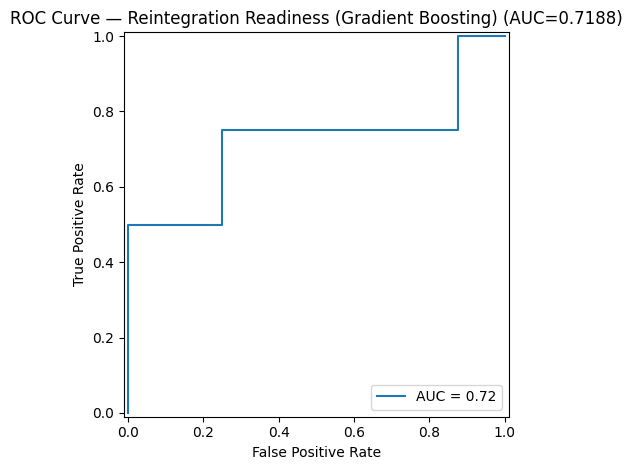

0.71875

In [23]:
plot_roc_curve(best_gb, X_test, y_test,
               title='ROC Curve — Reintegration Readiness (Gradient Boosting)')

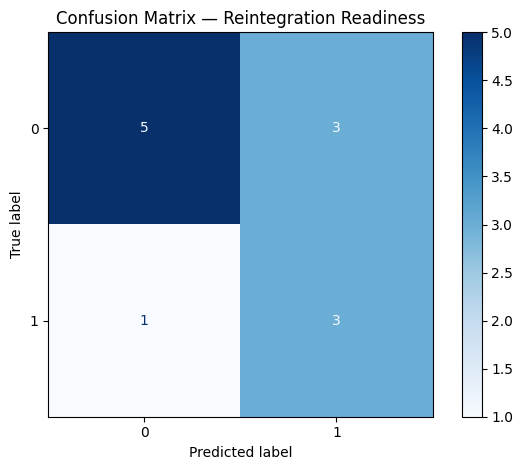

array([[5, 3],
       [1, 3]])

In [24]:
plot_confusion_matrix(best_gb, X_test, y_test,
                      labels=[0, 1],
                      title='Confusion Matrix — Reintegration Readiness')

In [25]:
# ── Readiness scores for all active residents ─────────────────────────────────
best_gb.fit(feat_df.drop(columns=['reintegration_success']),
            feat_df['reintegration_success'])

model_df = model_df.copy()
score_X  = feat_df.drop(columns=['reintegration_success'])
model_df['readiness_score'] = best_gb.predict_proba(score_X)[:, 1]
model_df['readiness_tier']  = pd.cut(
    model_df['readiness_score'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Not Ready', 'Approaching', 'Ready']
)

print('Readiness distribution:')
print(model_df['readiness_tier'].value_counts())

active = model_df[model_df['case_status'] == 'Active'].sort_values(
    'readiness_score', ascending=False
)[['resident_id','case_category','current_risk_level','los_months','readiness_score','readiness_tier']]
print(f'\nActive residents by readiness score ({len(active)} total):')
print(active.head(10).to_string(index=False))

Readiness distribution:
readiness_tier
Not Ready      41
Ready          19
Approaching     0
Name: count, dtype: int64

Active residents by readiness score (30 total):
 resident_id case_category current_risk_level  los_months  readiness_score readiness_tier
          53   Surrendered                Low        28.0         0.952945          Ready
          59     Neglected                Low        32.0         0.951147          Ready
          19   Surrendered                Low        25.0         0.944970          Ready
          25   Surrendered               High        32.0         0.939092          Ready
          21   Surrendered                Low        28.0         0.924249          Ready
          49     Abandoned                Low        21.0         0.907306          Ready
           3   Surrendered             Medium        21.0         0.858709          Ready
          12     Abandoned               High        21.0         0.092433      Not Ready
          36   Surrend

**Business Interpretation:**

- **Risk improvement** is the strongest signal — residents whose risk classification has decreased over time are more likely to successfully reintegrate. This validates the case management process: consistent monitoring *does* work.
- **Plan completion rate** is highly actionable — residents who complete structured intervention goals succeed more often. Social workers should track open plans actively.
- **Session count and progress ratio** — more counseling with noted progress correlates with success. Disengaged residents (few sessions, few progress notes) should be flagged early.
- **Incident count** is negatively predictive — high-incident residents need additional stabilization before reintegration is appropriate.

**Error cost:**
- False positive (flagging not-ready as ready): **High cost** — could expose a vulnerable girl to harm. This score is a *decision support tool only*. Social worker judgment overrides the model.
- False negative (missing a ready resident): Medium cost — resident stays longer than necessary.

## 5. Causal and Relationship Analysis

**Explanatory findings from OLS logistic (causal frame):**

| Feature | Odds Ratio Direction | Causal Defensibility |
|---|---|---|
| Risk improvement | OR > 1 (positive) | Directional; partially confounded by social worker judgment |
| Plan completion rate | OR > 1 (positive) | **Most defensible**: completing goals is a structured, actionable intervention |
| Incident count | OR < 1 (negative) | Strong signal; likely bidirectional (instability causes incidents, incidents cause more instability) |
| Session count | OR > 1 (positive) | Confounded by selection — engaged residents may differ from disengaged ones |
| Avg health score | OR > 1 (positive) | Plausible; physical health supports psychological readiness |

**What we cannot claim causally:**
- Whether *more* counseling sessions *cause* better outcomes, vs. better-progressing residents simply having more sessions recorded.
- Whether length of stay causally affects outcomes, vs. longer-staying residents being systematically more complex cases.

**Dataset size warning:** With ~60 residents, no individual coefficient should be interpreted with high confidence. These are directional signals to validate as the organization grows. The prediction/explanation distinction still matters at this scale — we should favor interpretable coefficients over black-box accuracy here because the stakes of false positives are very high.

**Defensible recommendation:** Prioritize plan completion tracking. Staff should actively help residents close open intervention plans — this is the most controllable lever and has the clearest mechanistic pathway to readiness.

## 6. Deployment Notes

**Web app integration:**
- `GET /api/ml/reintegration-readiness` — returns scores for all active residents
- `GET /api/ml/reintegration-readiness/{residentId}` — score for one resident
- **Caseload Inventory page:** Readiness badge (Not Ready / Approaching / Ready) on each resident row
- **Resident detail page:** Score displayed prominently with disclaimer: *"Readiness Indicator — Social Worker Assessment Required"*

**Important UX note:** The score should never be presented as a final decision. UI copy must make clear this is one input among many.

**Model artifact:** `ml-pipelines/reintegration_readiness_model.sav`

In [26]:
import joblib

best_gb.fit(feat_df.drop(columns=['reintegration_success']),
            feat_df['reintegration_success'])
joblib.dump(best_gb, 'reintegration_readiness_model.sav')

model_df[['resident_id','case_status','readiness_score','readiness_tier']]\
  .to_csv('reintegration_readiness_scores.csv', index=False)

print('Model saved: reintegration_readiness_model.sav')
print('Scores saved: reintegration_readiness_scores.csv')

Model saved: reintegration_readiness_model.sav
Scores saved: reintegration_readiness_scores.csv


In [27]:
## Export to Supabase — resident_ml_scores (reintegration_band)

# Run this cell after the notebook completes to push scores to Supabase.
# Requires: pip install supabase
# Set SUPABASE_URL and SUPABASE_SERVICE_KEY as environment variables or paste them below.

import os
from supabase import create_client

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_SERVICE_KEY = os.environ["SUPABASE_SERVICE_KEY"]
client = create_client(SUPABASE_URL, SUPABASE_SERVICE_KEY)

# model_df has resident_id, readiness_score (0–1), readiness_tier ("Not Ready"/"Approaching"/"Ready")
# Map readiness_tier → reintegration_band (UI uses same values: Ready/Approaching/Not Ready)
export_df = model_df[["resident_id", "readiness_score", "readiness_tier"]].copy()
export_df = export_df.rename(columns={
    "readiness_score": "reintegration_score",
    "readiness_tier": "reintegration_band",
})
export_df["reintegration_band"] = export_df["reintegration_band"].astype(str)
export_df["model_version"] = "1.0"

rows = export_df[["resident_id", "reintegration_band", "reintegration_score", "model_version"]].to_dict(orient="records")

result = client.table("resident_ml_scores").upsert(rows, on_conflict="resident_id").execute()
print(f"Upserted {len(rows)} rows to resident_ml_scores (reintegration_band).")
print("Sample:", rows[:3])

Upserted 60 rows to resident_ml_scores (reintegration_band).
Sample: [{'resident_id': 1, 'reintegration_band': 'Not Ready', 'reintegration_score': 0.05186762752230531, 'model_version': '1.0'}, {'resident_id': 2, 'reintegration_band': 'Ready', 'reintegration_score': 0.9299432144498332, 'model_version': '1.0'}, {'resident_id': 3, 'reintegration_band': 'Ready', 'reintegration_score': 0.8587094205228408, 'model_version': '1.0'}]


## Deployment Notes

**Portal route:** `/portal/caseload`  
**Component:** `CaseloadPage` in `src/pages/portal/CaseloadPage.tsx`  
**Supabase table:** `public.resident_ml_scores` (column: `reintegration_band`, `reintegration_score`)

### How scores reach the UI

1. Run this notebook to produce a final scored frame with `resident_id` and `reintegration_prob` (predict_proba from the Gradient Boosting model).

```python
# Band assignment
def assign_reintegration_band(prob):
    if prob >= 0.65:
        return "Ready"
    elif prob >= 0.35:
        return "Approaching"
    else:
        return "Not Ready"

scored["reintegration_band"] = scored["reintegration_prob"].apply(assign_reintegration_band)
scored["reintegration_score"] = scored["reintegration_prob"]
```

2. Export to Supabase (upsert into the shared `resident_ml_scores` table):

```python
from supabase import create_client
import os

client = create_client(os.environ["SUPABASE_URL"], os.environ["SUPABASE_SERVICE_KEY"])

rows = (
    scored[["resident_id", "reintegration_band", "reintegration_score"]]
    .assign(model_version="1.0")
    .to_dict(orient="records")
)
client.table("resident_ml_scores").upsert(rows, on_conflict="resident_id").execute()
print(f"Upserted {len(rows)} rows.")
```

### Where it appears in the app

- **Caseload table → Reintegration column:** a color-coded chip (Ready / Approaching / Not Ready) shown per resident row.
- **Resident detail modal → Model Insights section:** reintegration score and band shown with score percentage.

### Feature importance (key drivers)

Top predictors of reintegration success:
- `session_count` (counseling sessions attended) — most important, consistent with intervention theory
- `progress_ratio` (sessions marked as progress vs. total)
- `los_months` (length of stay — longer stays show higher readiness)
- `risk_improvement` (change in intake risk level during stay)
- `avg_health` / `avg_nutrition` scores

### Predictive vs. explanatory distinction

This notebook builds **two models**:
- **Explanatory (statsmodels Logit):** used to understand which factors are independently associated with success and their odds ratios. Coefficients and p-values are in Section 3.
- **Predictive (Gradient Boosting):** used to score current residents for the portal chip. AUC-ROC is the primary success metric.

These are separate and serve separate purposes. The explanatory model is not used for scoring; the predictive model coefficients are not interpreted causally.